In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

from qop_lop_solvers import generate_data, loss, solve_lop, solve_lop_clipped, solve_qop

np.random.seed(42)

In [2]:
# Global constants
n = 300
d = 100
xi = 5.0
K = 1000
RUNS = 10
lam_l1 = 1
rho = 1

eps = 0.5
delta = 0.01
noise_theta = 0.1

kappas = np.logspace(-2, 3, 100)

In [3]:
methods = {
    "lop": {
        "label": "LOP",
        "solver": solve_lop,
    },
    "lop_clip": {
        "label": "LOP-Clip",
        "solver": solve_lop_clipped,
    },
    "qop": {
        "label": "QOP",
        "solver": solve_qop,
    },
}


def run_case():
    X, y, true_theta = generate_data(n, d, xi)

    theta = true_theta + noise_theta * np.random.randn(d)
    result = {
        method: {
            "loss": [],
            "std": [],
            "stderr": [],
            "time": [],
        }
        for method in methods
    }

    for kappa in kappas:
        values = {method: [] for method in methods}
        total_time = {method: 0.0 for method in methods}

        for _ in range(RUNS):
            for method, config in methods.items():
                start = perf_counter()
                fitted_theta = config["solver"](X, y, theta, eps, delta, kappa, n, d, xi, K, lam_l1, rho)
                total_time[method] += perf_counter() - start
                values[method].append(loss(fitted_theta, X, y))

        for method, method_values in values.items():
            method_values = np.asarray(method_values)
            method_std = np.std(method_values, ddof=1) if RUNS > 1 else 0.0

            result[method]["loss"].append(np.mean(method_values))
            result[method]["std"].append(method_std)
            result[method]["stderr"].append(method_std / np.sqrt(RUNS))
            result[method]["time"].append(total_time[method] / RUNS)

    return result

In [4]:
result = run_case()

In [5]:
from IPython.display import Markdown, display

error_rows = []
for method, config in methods.items():
    std_values = np.asarray(result[method]["std"])
    stderr_values = np.asarray(result[method]["stderr"])
    time_values = np.asarray(result[method]["time"])
    error_rows.append(
        {
            "method": config["label"],
            "avg_std": np.mean(std_values),
            "max_std": np.max(std_values),
            "avg_stderr": np.mean(stderr_values),
            "max_stderr": np.max(stderr_values),
            "avg_time_s": np.mean(time_values),
        }
    )

error_table = [
    "| Method | Avg Std | Max Std | Avg SE | Max SE | Avg Execute Time / Run (s) |",
    "|---|---:|---:|---:|---:|---:|",
]
error_table.extend(
    f"| {row['method']} | {row['avg_std']:.6g} | {row['max_std']:.6g} | {row['avg_stderr']:.6g} | {row['max_stderr']:.6g} | {row['avg_time_s']:.6g} |"
    for row in error_rows
)

display(Markdown("\n".join(error_table)))

| Method | Avg Std | Max Std | Avg SE | Max SE | Avg Execute Time / Run (s) |
|---|---:|---:|---:|---:|---:|
| LOP | 38148.1 | 679871 | 12063.5 | 214994 | 0.00801949 |
| LOP-Clip | 45.4092 | 185.503 | 14.3597 | 58.6613 | 0.00875686 |
| QOP | 0.0732116 | 0.395936 | 0.0231515 | 0.125206 | 0.0124812 |

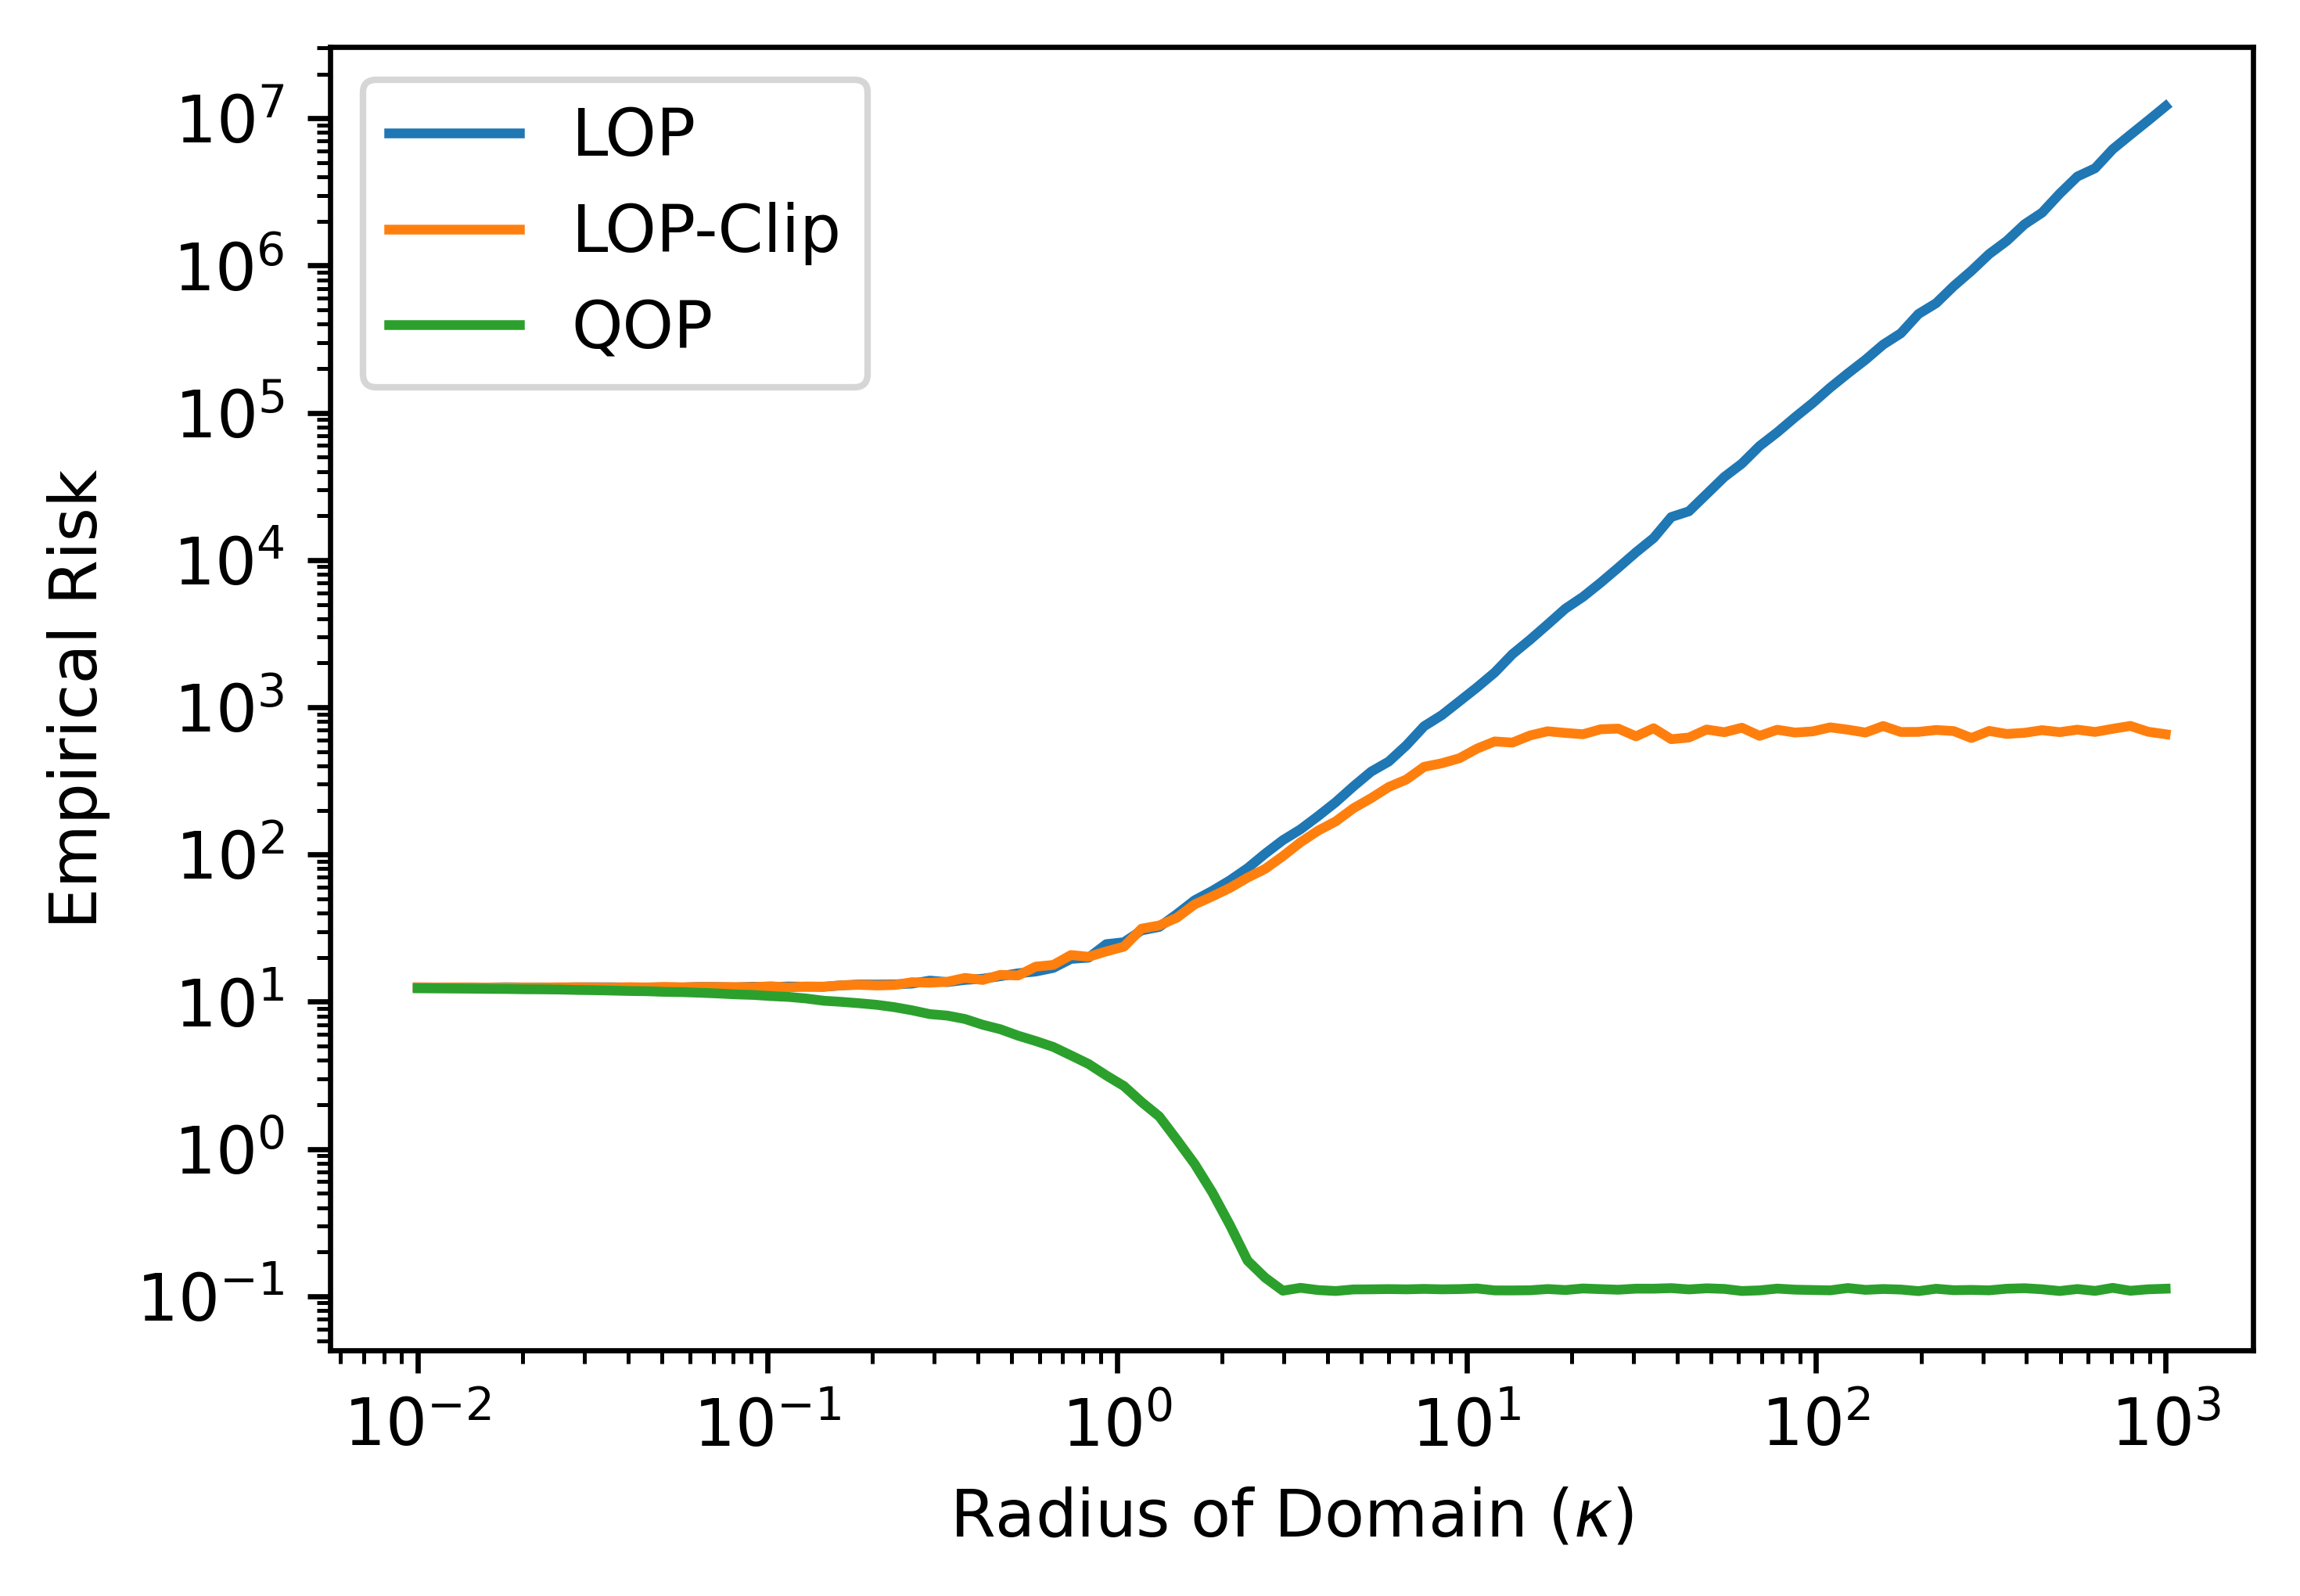

In [6]:
fig, ax = plt.subplots(dpi=600, figsize=(5, 3.5))

for method, config in methods.items():
    ax.plot(kappas, result[method]["loss"], label=config["label"])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Radius of Domain ($\kappa$)")
ax.set_ylabel("Empirical Risk")
ax.legend()

fig.tight_layout()
plt.show()